******Week 11 - Clustering Part 2: DBSCAN and Hierarchical Agglomerative Clustering******


In [1]:
%pip install -q pandas numpy matplotlib scipy scikit-learn kagglehub


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import sklearn
import kagglehub

from scipy.cluster.hierarchy import (
    cophenet,
    dendrogram,
    fcluster,
    linkage
)
from scipy.spatial.distance import pdist
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

print(f"scikit-learn version: {sklearn.__version__}")
print(f"scipy version: {scipy.__version__}")
print("All imports successful.")

scikit-learn version: 1.9.0
scipy version: 1.18.0
All imports successful.


**Data Loading and Cleaning**


In [3]:
path = kagglehub.dataset_download("laotse/credit-risk-dataset")
df = pd.read_csv(f"{path}/credit_risk_dataset.csv")

print(f"Raw shape: {df.shape}")

df = df.drop_duplicates().copy()

df["person_emp_length"] = df["person_emp_length"].fillna(
    df["person_emp_length"].median()
)

df["loan_int_rate"] = df["loan_int_rate"].fillna(
    df.groupby("loan_grade")["loan_int_rate"].transform("median")
)

df = df[df["person_emp_length"] <= df["person_age"]]
df = df[df["person_age"] <= 100]
df = df[df["person_emp_length"] <= 60]

print(f"Clean shape: {df.shape}")
print(f"Default rate: {df['loan_status'].mean() * 100:.2f}%")

Raw shape: (32581, 12)
Clean shape: (32409, 12)
Default rate: 21.87%


**Feature Preparation and the Sampling Decision**

In [4]:
numeric_features = [
    "person_income",
    "person_age",
    "person_emp_length",
    "loan_amnt",
    "loan_percent_income",
    "loan_int_rate"
]

categorical_features = [
    "loan_intent",
    "loan_grade",
    "person_home_ownership",
    "cb_person_default_on_file"
]

X = df[numeric_features + categorical_features].copy()
y_holdout = df["loan_status"].copy()

complete_mask = X.notna().all(axis=1)
X = X.loc[complete_mask]
y_holdout = y_holdout.loc[complete_mask]
df_model = df.loc[complete_mask].copy()

scaled_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

X_scaled = np.asarray(
    scaled_preprocessor.fit_transform(X),
    dtype=np.float64
)

categorical_names = (
    scaled_preprocessor.named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
    .tolist()
)
feature_names = numeric_features + categorical_names

sample_rng = np.random.default_rng(42)

dbscan_sample_size = 12000
hierarchical_sample_size = 4000
dendrogram_sample_size = 1200

dbscan_indices = sample_rng.choice(
    X_scaled.shape[0],
    size=min(dbscan_sample_size, X_scaled.shape[0]),
    replace=False
)

hierarchical_indices = sample_rng.choice(
    X_scaled.shape[0],
    size=min(hierarchical_sample_size, X_scaled.shape[0]),
    replace=False
)

dendrogram_indices = hierarchical_indices[:dendrogram_sample_size]

X_dbscan = X_scaled[dbscan_indices]
y_dbscan = y_holdout.values[dbscan_indices]
df_dbscan = df_model.iloc[dbscan_indices].copy()

X_hierarchical = X_scaled[hierarchical_indices]
y_hierarchical = y_holdout.values[hierarchical_indices]
df_hierarchical = df_model.iloc[hierarchical_indices].copy()

X_dendrogram = X_scaled[dendrogram_indices]

print(f"Full population available: {X_scaled.shape[0]:,} borrowers")
print(f"Feature space dimensions: {X_scaled.shape[1]}")
print(f"DBSCAN working sample: {X_dbscan.shape[0]:,}")
print(f"Hierarchical working sample: {X_hierarchical.shape[0]:,}")
print(f"Dendrogram display sample: {X_dendrogram.shape[0]:,}")
print(f"\nWithheld default rate, full population: {y_holdout.mean() * 100:.2f}%")
print(f"Withheld default rate, DBSCAN sample: {y_dbscan.mean() * 100:.2f}%")
print(
    f"Withheld default rate, hierarchical sample: "
    f"{y_hierarchical.mean() * 100:.2f}%"
)

Full population available: 32,409 borrowers
Feature space dimensions: 25
DBSCAN working sample: 12,000
Hierarchical working sample: 4,000
Dendrogram display sample: 1,200

Withheld default rate, full population: 21.87%
Withheld default rate, DBSCAN sample: 22.18%
Withheld default rate, hierarchical sample: 22.25%


**Choosing eps: The k-Distance Graph**


Rule-of-thumb min_samples for 25 dimensions (twice the dimension count): 50

Distribution of the k-th Nearest Neighbour Distance
  50th percentile: 1.6573
  75th percentile: 1.9641
  90th percentile: 2.3184
  95th percentile: 2.6218
  97th percentile: 2.8309
  99th percentile: 3.4156

Estimated knee at index 9,718 of 12,000
That is the 81.0th percentile of the k-distance curve
Suggested eps from the k-distance graph: 2.0781


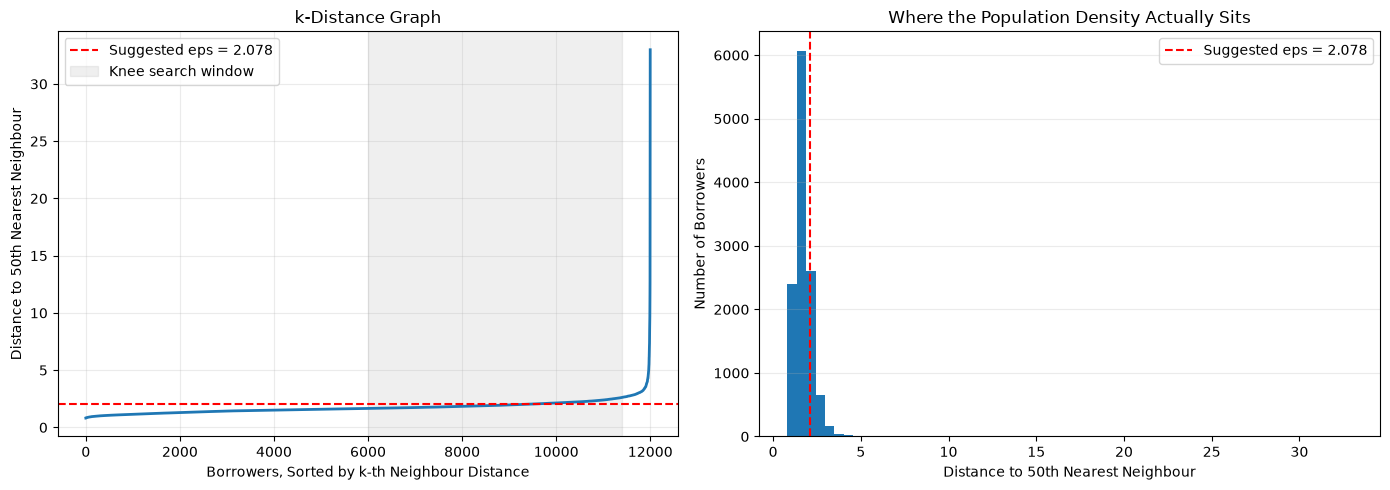

In [5]:
min_samples_reference = 2 * X_dbscan.shape[1]

print(
    f"Rule-of-thumb min_samples for {X_dbscan.shape[1]} dimensions "
    f"(twice the dimension count): {min_samples_reference}"
)

neighbour_model = NearestNeighbors(n_neighbors=min_samples_reference)
neighbour_model.fit(X_dbscan)

neighbour_distances, _ = neighbour_model.kneighbors(X_dbscan)

kth_distances = np.sort(neighbour_distances[:, -1])
n_points = len(kth_distances)

percentile_points = [50, 75, 90, 95, 97, 99]

print("\nDistribution of the k-th Nearest Neighbour Distance")
for percentile in percentile_points:
    print(
        f"  {percentile}th percentile: "
        f"{np.percentile(kth_distances, percentile):.4f}"
    )


lower_bound = int(0.50 * n_points)
upper_bound = int(0.95 * n_points)

segment_x = np.arange(lower_bound, upper_bound, dtype=float)
segment_y = kth_distances[lower_bound:upper_bound]

x_norm = (segment_x - segment_x[0]) / (segment_x[-1] - segment_x[0])
y_norm = (segment_y - segment_y[0]) / (segment_y[-1] - segment_y[0])

chord_gap = x_norm - y_norm

knee_position = lower_bound + int(np.argmax(chord_gap))
knee_eps = float(kth_distances[knee_position])
knee_percentile = 100.0 * knee_position / n_points

print(f"\nEstimated knee at index {knee_position:,} of {n_points:,}")
print(
    f"That is the {knee_percentile:.1f}th percentile "
    "of the k-distance curve"
)
print(f"Suggested eps from the k-distance graph: {knee_eps:.4f}")

if knee_percentile > 97.0:
    print(
        "[Warning] The knee sits in the outlier tail. Treat this eps as an "
        "upper bound rather than a starting point, or DBSCAN will merge the "
        "whole population into a single cluster."
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(kth_distances, linewidth=2)
axes[0].axhline(
    knee_eps,
    linestyle="--",
    color="red",
    label=f"Suggested eps = {knee_eps:.3f}"
)
axes[0].axvspan(
    lower_bound,
    upper_bound,
    color="grey",
    alpha=0.12,
    label="Knee search window"
)
axes[0].set_xlabel("Borrowers, Sorted by k-th Neighbour Distance")
axes[0].set_ylabel(f"Distance to {min_samples_reference}th Nearest Neighbour")
axes[0].set_title("k-Distance Graph")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].hist(kth_distances, bins=60)
axes[1].axvline(
    knee_eps,
    linestyle="--",
    color="red",
    label=f"Suggested eps = {knee_eps:.3f}"
)
axes[1].set_xlabel(f"Distance to {min_samples_reference}th Nearest Neighbour")
axes[1].set_ylabel("Number of Borrowers")
axes[1].set_title("Where the Population Density Actually Sits")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

**DBSCAN Parameter Sweep**

The sweep below varies `eps` around the suggested value and `min_samples` across three settings, and
reports what each combination produces. Four outputs are tracked, and reading them together is the
whole skill:

- **Clusters found** is discovered rather than specified. One cluster means `eps` was large enough to
  connect the entire population into a single blob; dozens of tiny clusters means it was too small and
  the algorithm is fragmenting the dense core.
- **Noise share** is the fraction of borrowers assigned no cluster. A very low figure means DBSCAN is
  behaving like K-Means and absorbing everyone; a very high figure means it found little density
  anywhere.
- **Silhouette excluding noise** measures separation among the clustered points only. Including noise
  would corrupt the score, since noise is not a cluster and its members are not supposed to be near
  each other.
- **Largest cluster share** exposes the most common outcome on data like this: one enormous cluster
  plus a handful of specks, which is a degenerate result even when the silhouette looks respectable.

eps values tested: [0.6234, 0.9351, 1.2468, 1.6624, 2.0781, 2.5976]
min_samples values tested: [12, 25, 50]

DBSCAN Parameter Sweep
   eps  min_samples  Clusters Found  Noise Share  Silhouette (no noise)  Largest Cluster Share  Noise Default Rate
0.6234           12              26       0.9203                 0.3276                 0.0103              0.2354
0.6234           25               2       0.9957                    NaN                 0.0022              0.2225
0.6234           50               0       1.0000                    NaN                    NaN              0.2218
0.9351           12              49       0.5616                 0.1624                 0.0283              0.3052
0.9351           25              23       0.7488                 0.2456                 0.0243              0.2690
0.9351           50               8       0.9228                 0.3348                 0.0158              0.2355
1.2468           12              64       0.3310               

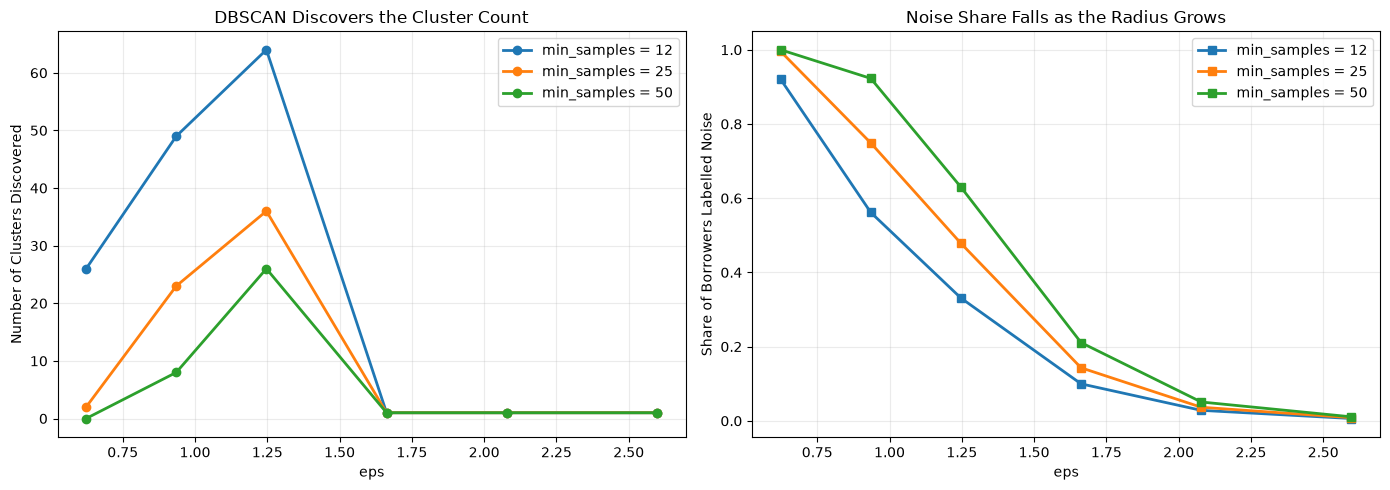

In [6]:
eps_candidates = [
    round(knee_eps * multiplier, 4)
    for multiplier in [0.30, 0.45, 0.60, 0.80, 1.00, 1.25]
]

min_samples_candidates = [
    max(5, min_samples_reference // 4),
    max(10, min_samples_reference // 2),
    min_samples_reference
]

print(f"eps values tested: {eps_candidates}")
print(f"min_samples values tested: {min_samples_candidates}")

dbscan_sweep_results = []
dbscan_label_store = {}

for eps_value in eps_candidates:
    for min_samples_value in min_samples_candidates:
        model = DBSCAN(
            eps=eps_value,
            min_samples=min_samples_value,
            n_jobs=-1
        )

        labels = model.fit_predict(X_dbscan)

        noise_mask = labels == -1
        clustered_mask = ~noise_mask

        unique_clusters = np.unique(labels[clustered_mask])
        cluster_count = len(unique_clusters)

        if cluster_count >= 2 and clustered_mask.sum() > 100:
            silhouette = silhouette_score(
                X_dbscan[clustered_mask],
                labels[clustered_mask],
                sample_size=min(4000, int(clustered_mask.sum())),
                random_state=42
            )
        else:
            silhouette = np.nan

        if cluster_count >= 1:
            largest_share = (
                pd.Series(labels[clustered_mask]).value_counts().iloc[0]
                / len(labels)
            )
        else:
            largest_share = np.nan

        if noise_mask.sum() > 0:
            noise_default_rate = y_dbscan[noise_mask].mean()
        else:
            noise_default_rate = np.nan

        dbscan_sweep_results.append({
            "eps": eps_value,
            "min_samples": min_samples_value,
            "Clusters Found": cluster_count,
            "Noise Share": noise_mask.mean(),
            "Silhouette (no noise)": silhouette,
            "Largest Cluster Share": largest_share,
            "Noise Default Rate": noise_default_rate
        })

        dbscan_label_store[(eps_value, min_samples_value)] = labels

dbscan_sweep_df = pd.DataFrame(dbscan_sweep_results)

print("\nDBSCAN Parameter Sweep")
print(dbscan_sweep_df.round(4).to_string(index=False))

multi_cluster_options = dbscan_sweep_df[
    (dbscan_sweep_df["Clusters Found"] >= 2)
    & (dbscan_sweep_df["Noise Share"] < 0.60)
    & (dbscan_sweep_df["Largest Cluster Share"] < 0.98)
].copy()

core_and_noise_options = dbscan_sweep_df[
    (dbscan_sweep_df["Clusters Found"] == 1)
    & (dbscan_sweep_df["Noise Share"] > 0.02)
    & (dbscan_sweep_df["Noise Share"] < 0.50)
].copy()

if len(multi_cluster_options) > 0:
    chosen = multi_cluster_options.loc[
        multi_cluster_options["Silhouette (no noise)"].idxmax()
    ]
    selection_regime = "multiple dense clusters"
elif len(core_and_noise_options) > 0:
    chosen = core_and_noise_options.loc[
        core_and_noise_options["Noise Share"].idxmax()
    ]
    selection_regime = "single dense core plus noise"
else:
    chosen = dbscan_sweep_df.loc[
        dbscan_sweep_df["Clusters Found"].idxmax()
    ]
    selection_regime = "fully degenerate"

chosen_eps = float(chosen["eps"])
chosen_min_samples = int(chosen["min_samples"])

print(
    f"\nSelected configuration: eps={chosen_eps}, "
    f"min_samples={chosen_min_samples}"
)
print(f"  Regime: {selection_regime}")
print(
    f"  Clusters: {int(chosen['Clusters Found'])}, "
    f"noise share: {chosen['Noise Share']:.4f}"
)

if selection_regime == "multiple dense clusters":
    print(
        "\n DBSCAN located more than one region of genuine "
        "density, so the population is not a single undifferentiated mass. "
        "Section 9 tests whether these regions correspond to the segments "
        "K-Means and Ward found."
    )
elif selection_regime == "single dense core plus noise":
    print(
        "\n Across the entire parameter grid DBSCAN found one "
        "dense region rather than several, with the remainder labelled "
        "noise. This is not a tuning failure, it is a substantive finding "
        "about the shape of the portfolio: borrower attributes form one "
        "continuous mass with sparse atypical applicants at its edges, "
        "rather than several distinct populations. It also means the "
        "K-Means partition of Week 10 was imposing boundaries on a "
        "continuum rather than discovering natural separations, which is "
        "the single most important caveat on any segmentation reported from "
        "this dataset. The core-versus-noise split remains directly useful, "
        "and Section 5 tests it against the withheld outcome."
    )
else:
    print(
        "\n No configuration produced either multiple clusters "
        "or a usable core-and-noise split. Falling back to the setting "
        "finding the most clusters. The degeneracy is itself the result: "
        "on a dense continuous population in twenty-five dimensions, "
        "nineteen of them binary, density-based clustering has no sparse "
        "gaps to exploit."
    )

dbscan_labels = dbscan_label_store[(chosen_eps, chosen_min_samples)]

pivot_clusters = dbscan_sweep_df.pivot(
    index="eps",
    columns="min_samples",
    values="Clusters Found"
)

pivot_noise = dbscan_sweep_df.pivot(
    index="eps",
    columns="min_samples",
    values="Noise Share"
)

print("\nClusters Found by Parameter Combination")
print(pivot_clusters.to_string())

print("\nNoise Share by Parameter Combination")
print(pivot_noise.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for min_samples_value in min_samples_candidates:
    subset = dbscan_sweep_df[
        dbscan_sweep_df["min_samples"] == min_samples_value
    ]
    axes[0].plot(
        subset["eps"],
        subset["Clusters Found"],
        marker="o",
        linewidth=2,
        label=f"min_samples = {min_samples_value}"
    )
    axes[1].plot(
        subset["eps"],
        subset["Noise Share"],
        marker="s",
        linewidth=2,
        label=f"min_samples = {min_samples_value}"
    )

axes[0].set_xlabel("eps")
axes[0].set_ylabel("Number of Clusters Discovered")
axes[0].set_title("DBSCAN Discovers the Cluster Count")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].set_xlabel("eps")
axes[1].set_ylabel("Share of Borrowers Labelled Noise")
axes[1].set_title("Noise Share Falls as the Radius Grows")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

**The Noise Points Are the Finding**


Borrowers labelled noise: 5,741 (47.84%)
Borrowers assigned to a cluster: 6,259
Clusters discovered: 36

Typical Versus Atypical Borrowers
              Group  Borrowers  Median Income  Median Loan  Mean Debt Burden  Mean Interest Rate  Median Age  Default Rate
Clustered (typical)       6259        52000.0       7000.0            0.1496              9.6125        25.0        0.1232
   Noise (atypical)       5741        60000.0      10000.0            0.1932             12.6185        28.0        0.3292

Default rate lift for noise borrowers: 2.67x
 Borrowers with no dense neighbourhood default at a materially higher rate. DBSCAN has produced an unsupervised screen for atypical applications, which a lender could use to route files to manual underwriting without any labelled training data.


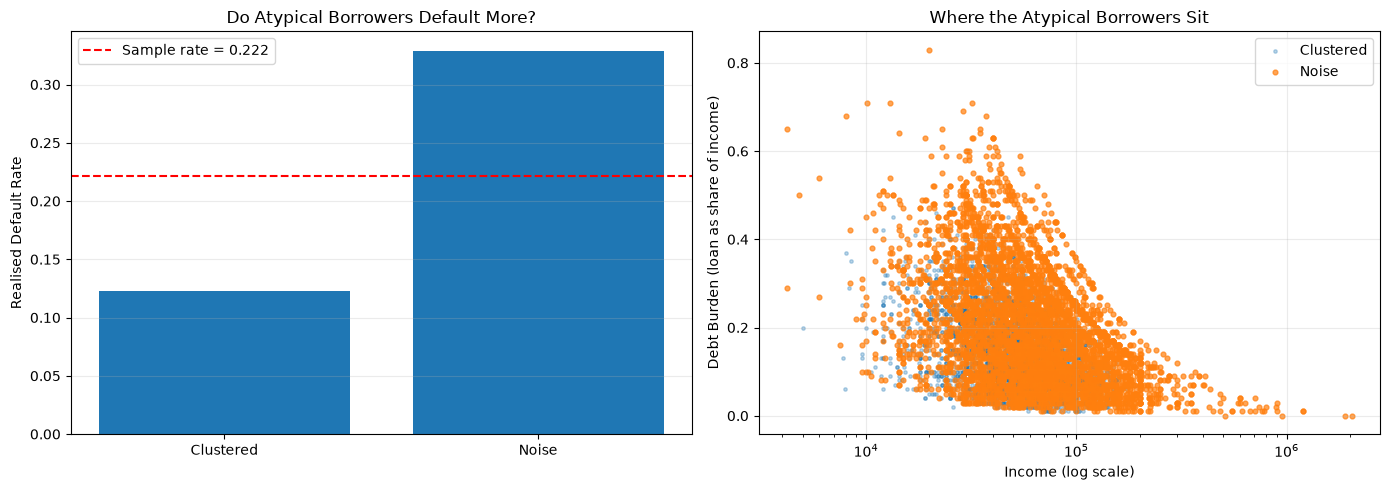

In [7]:
noise_mask = dbscan_labels == -1
clustered_mask = ~noise_mask

print(f"Borrowers labelled noise: {noise_mask.sum():,} ({noise_mask.mean():.2%})")
print(f"Borrowers assigned to a cluster: {clustered_mask.sum():,}")
print(f"Clusters discovered: {len(np.unique(dbscan_labels[clustered_mask]))}")

if noise_mask.sum() > 0 and clustered_mask.sum() > 0:
    noise_comparison = pd.DataFrame({
        "Group": ["Clustered (typical)", "Noise (atypical)"],
        "Borrowers": [clustered_mask.sum(), noise_mask.sum()],
        "Median Income": [
            df_dbscan.loc[clustered_mask, "person_income"].median(),
            df_dbscan.loc[noise_mask, "person_income"].median()
        ],
        "Median Loan": [
            df_dbscan.loc[clustered_mask, "loan_amnt"].median(),
            df_dbscan.loc[noise_mask, "loan_amnt"].median()
        ],
        "Mean Debt Burden": [
            df_dbscan.loc[clustered_mask, "loan_percent_income"].mean(),
            df_dbscan.loc[noise_mask, "loan_percent_income"].mean()
        ],
        "Mean Interest Rate": [
            df_dbscan.loc[clustered_mask, "loan_int_rate"].mean(),
            df_dbscan.loc[noise_mask, "loan_int_rate"].mean()
        ],
        "Median Age": [
            df_dbscan.loc[clustered_mask, "person_age"].median(),
            df_dbscan.loc[noise_mask, "person_age"].median()
        ],
        "Default Rate": [
            y_dbscan[clustered_mask].mean(),
            y_dbscan[noise_mask].mean()
        ]
    })

    print("\nTypical Versus Atypical Borrowers")
    print(noise_comparison.round(4).to_string(index=False))

    noise_lift = (
        y_dbscan[noise_mask].mean()
        / max(y_dbscan[clustered_mask].mean(), 1e-9)
    )

    print(f"\nDefault rate lift for noise borrowers: {noise_lift:.2f}x")

    if noise_lift > 1.25:
        print(
            " Borrowers with no dense neighbourhood default at a "
            "materially higher rate. DBSCAN has produced an unsupervised "
            "screen for atypical applications, which a lender could use to "
            "route files to manual underwriting without any labelled "
            "training data."
        )
    elif noise_lift < 0.80:
        print(
            " Noise borrowers default at a *lower* rate than the "
            "dense core. Atypical does not mean risky here, and a naive "
            "outlier-based decline rule would reject better-than-average "
            "business."
        )
    else:
        print(
            " Noise borrowers default at roughly the population "
            "rate. Being unusual in feature space carries no risk "
            "information on this dataset, which is a useful correction to an "
            "intuitive but unfounded assumption."
        )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(
        ["Clustered", "Noise"],
        [
            y_dbscan[clustered_mask].mean(),
            y_dbscan[noise_mask].mean()
        ]
    )
    axes[0].axhline(
        y_dbscan.mean(),
        linestyle="--",
        color="red",
        label=f"Sample rate = {y_dbscan.mean():.3f}"
    )
    axes[0].set_ylabel("Realised Default Rate")
    axes[0].set_title("Do Atypical Borrowers Default More?")
    axes[0].legend()
    axes[0].grid(axis="y", alpha=0.25)

    axes[1].scatter(
        df_dbscan.loc[clustered_mask, "person_income"],
        df_dbscan.loc[clustered_mask, "loan_percent_income"],
        s=6,
        alpha=0.3,
        label="Clustered"
    )
    axes[1].scatter(
        df_dbscan.loc[noise_mask, "person_income"],
        df_dbscan.loc[noise_mask, "loan_percent_income"],
        s=12,
        alpha=0.7,
        label="Noise"
    )
    axes[1].set_xscale("log")
    axes[1].set_xlabel("Income (log scale)")
    axes[1].set_ylabel("Debt Burden (loan as share of income)")
    axes[1].set_title("Where the Atypical Borrowers Sit")
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()
else:
    print(
        "\n This configuration produced no noise points or no "
        "clustered points, so the typical-versus-atypical comparison cannot "
        "be made. That degeneracy is itself informative about how DBSCAN "
        "behaves on a dense, continuous population in high dimensions."
    )

**Visualising DBSCAN Against K-Means**


Variance captured in this projection: 0.3815


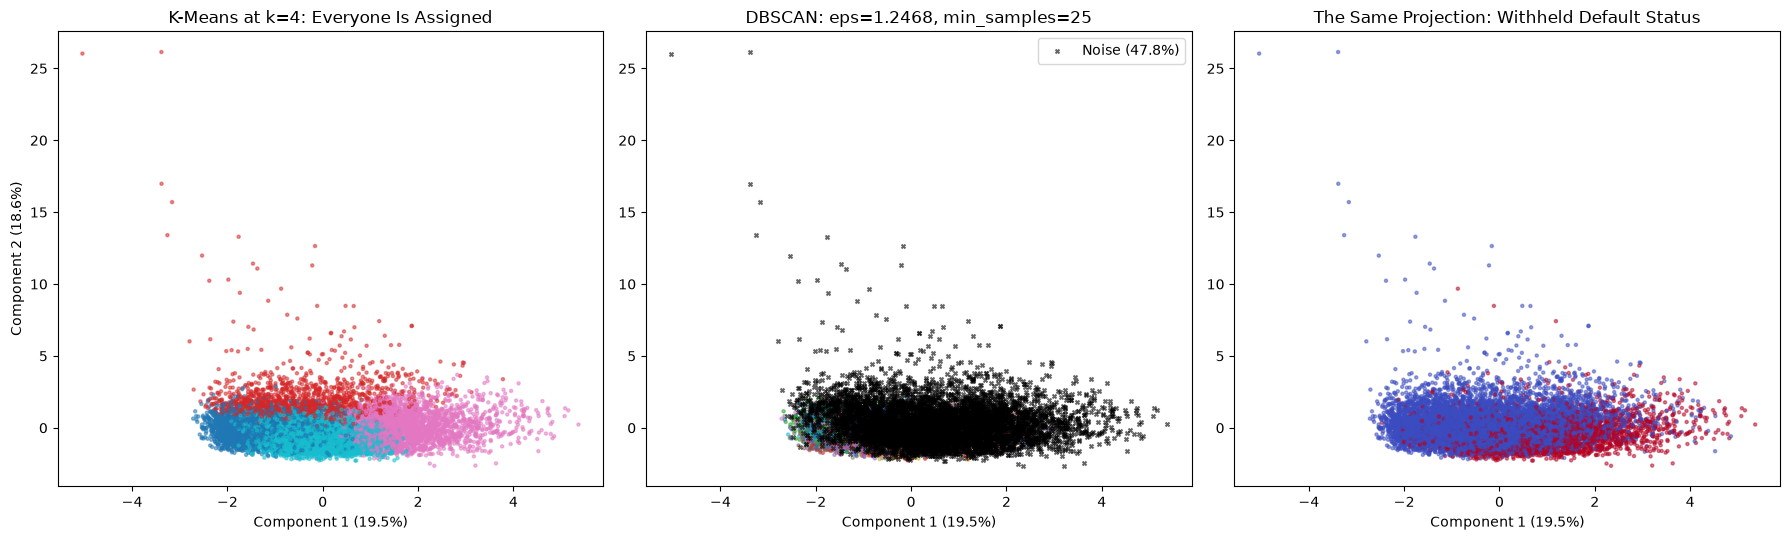

In [8]:
pca = PCA(n_components=2, random_state=42)
X_projected = pca.fit_transform(X_dbscan)

explained = pca.explained_variance_ratio_

print(f"Variance captured in this projection: {explained.sum():.4f}")

reference_kmeans_labels = KMeans(
    n_clusters=4,
    n_init=25,
    random_state=42
).fit_predict(X_dbscan)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

axes[0].scatter(
    X_projected[:, 0],
    X_projected[:, 1],
    c=reference_kmeans_labels,
    cmap="tab10",
    s=5,
    alpha=0.5
)
axes[0].set_title("K-Means at k=4: Everyone Is Assigned")
axes[0].set_xlabel(f"Component 1 ({explained[0]:.1%})")
axes[0].set_ylabel(f"Component 2 ({explained[1]:.1%})")

axes[1].scatter(
    X_projected[clustered_mask, 0],
    X_projected[clustered_mask, 1],
    c=dbscan_labels[clustered_mask],
    cmap="tab10",
    s=5,
    alpha=0.5
)
if noise_mask.sum() > 0:
    axes[1].scatter(
        X_projected[noise_mask, 0],
        X_projected[noise_mask, 1],
        c="black",
        s=8,
        alpha=0.6,
        marker="x",
        label=f"Noise ({noise_mask.mean():.1%})"
    )
    axes[1].legend()
axes[1].set_title(
    f"DBSCAN: eps={chosen_eps}, min_samples={chosen_min_samples}"
)
axes[1].set_xlabel(f"Component 1 ({explained[0]:.1%})")

axes[2].scatter(
    X_projected[:, 0],
    X_projected[:, 1],
    c=y_dbscan,
    cmap="coolwarm",
    s=5,
    alpha=0.5
)
axes[2].set_title("The Same Projection: Withheld Default Status")
axes[2].set_xlabel(f"Component 1 ({explained[0]:.1%})")

plt.tight_layout()
plt.show()

**Hierarchical Agglomerative Clustering**

The critical choice is the linkage method, which defines the distance between two *groups* of points
rather than two points. The definition matters more than intuition suggests:

- **Ward** merges whichever pair produces the smallest increase in total within-cluster variance. It is
  the closest analogue to the K-Means objective and tends to produce compact, similarly sized clusters.
  It requires Euclidean distance for the same reason K-Means does.
- **Complete** measures group distance as the distance between the two *furthest* members, so a merge
  is only cheap when every member of one group is close to every member of the other. This resists
  elongated clusters and produces compact ones.
- **Average** uses the mean distance across all cross-group pairs, a middle course between complete and
  single.
- **Single** uses the *closest* pair of members, so two groups merge if any one point in each is
  nearby. This can follow irregular shapes that the others cannot, but it is prone to chaining: a thin
  bridge of intermediate points causes two otherwise distinct groups to fuse, and one enormous
  straggling cluster absorbs almost everything.

The cophenetic correlation reported below measures how faithfully the tree's implied distances
reproduce the original pairwise distances, giving a single number for how much each linkage method
distorts the data.

Cophenetic Correlation by Linkage Method
(how faithfully the tree preserves original distances)
  ward      : 0.3366
  complete  : 0.6233
  average   : 0.7519
  single    : 0.7218

Highest cophenetic correlation: average

Hierarchical Clustering Across Linkage Methods and Cut Heights
 Linkage  Requested k  Actual Clusters  Silhouette  Davies-Bouldin  Largest Cluster Share  Default Rate Spread
    ward            2                2      0.1035          2.5803                 0.7665               0.2363
    ward            3                3      0.0826          2.4095                 0.5608               0.2944
    ward            4                4      0.0771          2.4071                 0.3432               0.3228
    ward            5                5      0.0913          2.1634                 0.3432               0.3228
    ward            6                6      0.0992          1.9246                 0.3432               0.3228
    ward            7                7      0.073

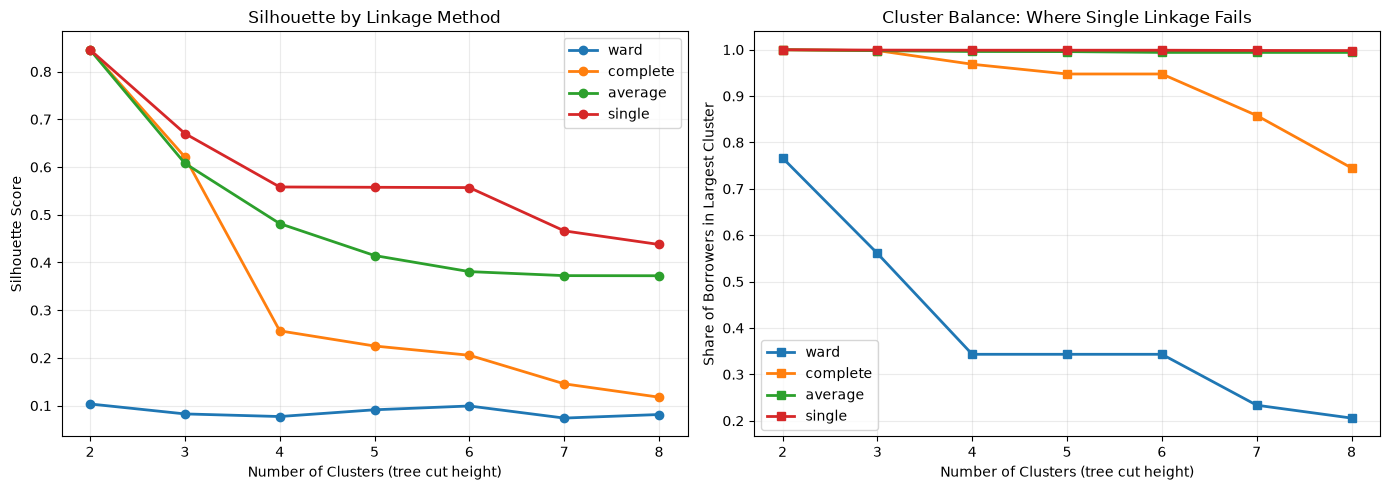

In [9]:
linkage_methods = ["ward", "complete", "average", "single"]

pairwise_condensed = pdist(X_hierarchical, metric="euclidean")

linkage_matrices = {}
cophenetic_scores = {}

for method in linkage_methods:
    linkage_matrix = linkage(
        X_hierarchical,
        method=method,
        metric="euclidean"
    )

    linkage_matrices[method] = linkage_matrix

    correlation, _ = cophenet(linkage_matrix, pairwise_condensed)
    cophenetic_scores[method] = correlation

print("Cophenetic Correlation by Linkage Method")
print("(how faithfully the tree preserves original distances)")
for method in linkage_methods:
    print(f"  {method:<10}: {cophenetic_scores[method]:.4f}")

best_cophenetic = max(cophenetic_scores, key=cophenetic_scores.get)
print(f"\nHighest cophenetic correlation: {best_cophenetic}")

hierarchical_results = []

cut_k_values = [2, 3, 4, 5, 6, 7, 8]

for method in linkage_methods:
    for k in cut_k_values:
        labels = fcluster(
            linkage_matrices[method],
            t=k,
            criterion="maxclust"
        )

        actual_clusters = len(np.unique(labels))

        if actual_clusters < 2:
            continue

        default_rate_by_cluster = pd.Series(
            y_hierarchical
        ).groupby(labels).mean()

        hierarchical_results.append({
            "Linkage": method,
            "Requested k": k,
            "Actual Clusters": actual_clusters,
            "Silhouette": silhouette_score(X_hierarchical, labels),
            "Davies-Bouldin": davies_bouldin_score(X_hierarchical, labels),
            "Largest Cluster Share": (
                pd.Series(labels).value_counts(normalize=True).iloc[0]
            ),
            "Default Rate Spread": (
                default_rate_by_cluster.max()
                - default_rate_by_cluster.min()
            )
        })

hierarchical_df = pd.DataFrame(hierarchical_results)

print("\nHierarchical Clustering Across Linkage Methods and Cut Heights")
print(hierarchical_df.round(4).to_string(index=False))

print("\nBalance Check: Largest Cluster Share by Linkage (averaged over k)")
balance_summary = hierarchical_df.groupby("Linkage").agg(
    Mean_Largest_Share=("Largest Cluster Share", "mean"),
    Mean_Silhouette=("Silhouette", "mean"),
    Mean_Default_Spread=("Default Rate Spread", "mean")
).round(4)
print(balance_summary.to_string())

single_share = balance_summary.loc["single", "Mean_Largest_Share"]
ward_share = balance_summary.loc["ward", "Mean_Largest_Share"]

print(
    f"\nSingle linkage puts {single_share:.1%} of borrowers in its largest "
    f"cluster on average; Ward puts {ward_share:.1%}."
)

if single_share > 0.90:
    print(
        " Single linkage has chained, exactly as the theory "
        "predicts on a dense continuous population. Almost every borrower "
        "ends up in one cluster with a few singletons split off. This is not "
        "a bug and it is worth reporting: it demonstrates that a linkage "
        "method can be entirely unsuitable for a dataset regardless of how "
        "it is tuned."
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for method in linkage_methods:
    subset = hierarchical_df[hierarchical_df["Linkage"] == method]
    axes[0].plot(
        subset["Requested k"],
        subset["Silhouette"],
        marker="o",
        linewidth=2,
        label=method
    )
    axes[1].plot(
        subset["Requested k"],
        subset["Largest Cluster Share"],
        marker="s",
        linewidth=2,
        label=method
    )

axes[0].set_xlabel("Number of Clusters (tree cut height)")
axes[0].set_ylabel("Silhouette Score")
axes[0].set_title("Silhouette by Linkage Method")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].set_xlabel("Number of Clusters (tree cut height)")
axes[1].set_ylabel("Share of Borrowers in Largest Cluster")
axes[1].set_title("Cluster Balance: Where Single Linkage Fails")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

**Dendrograms**


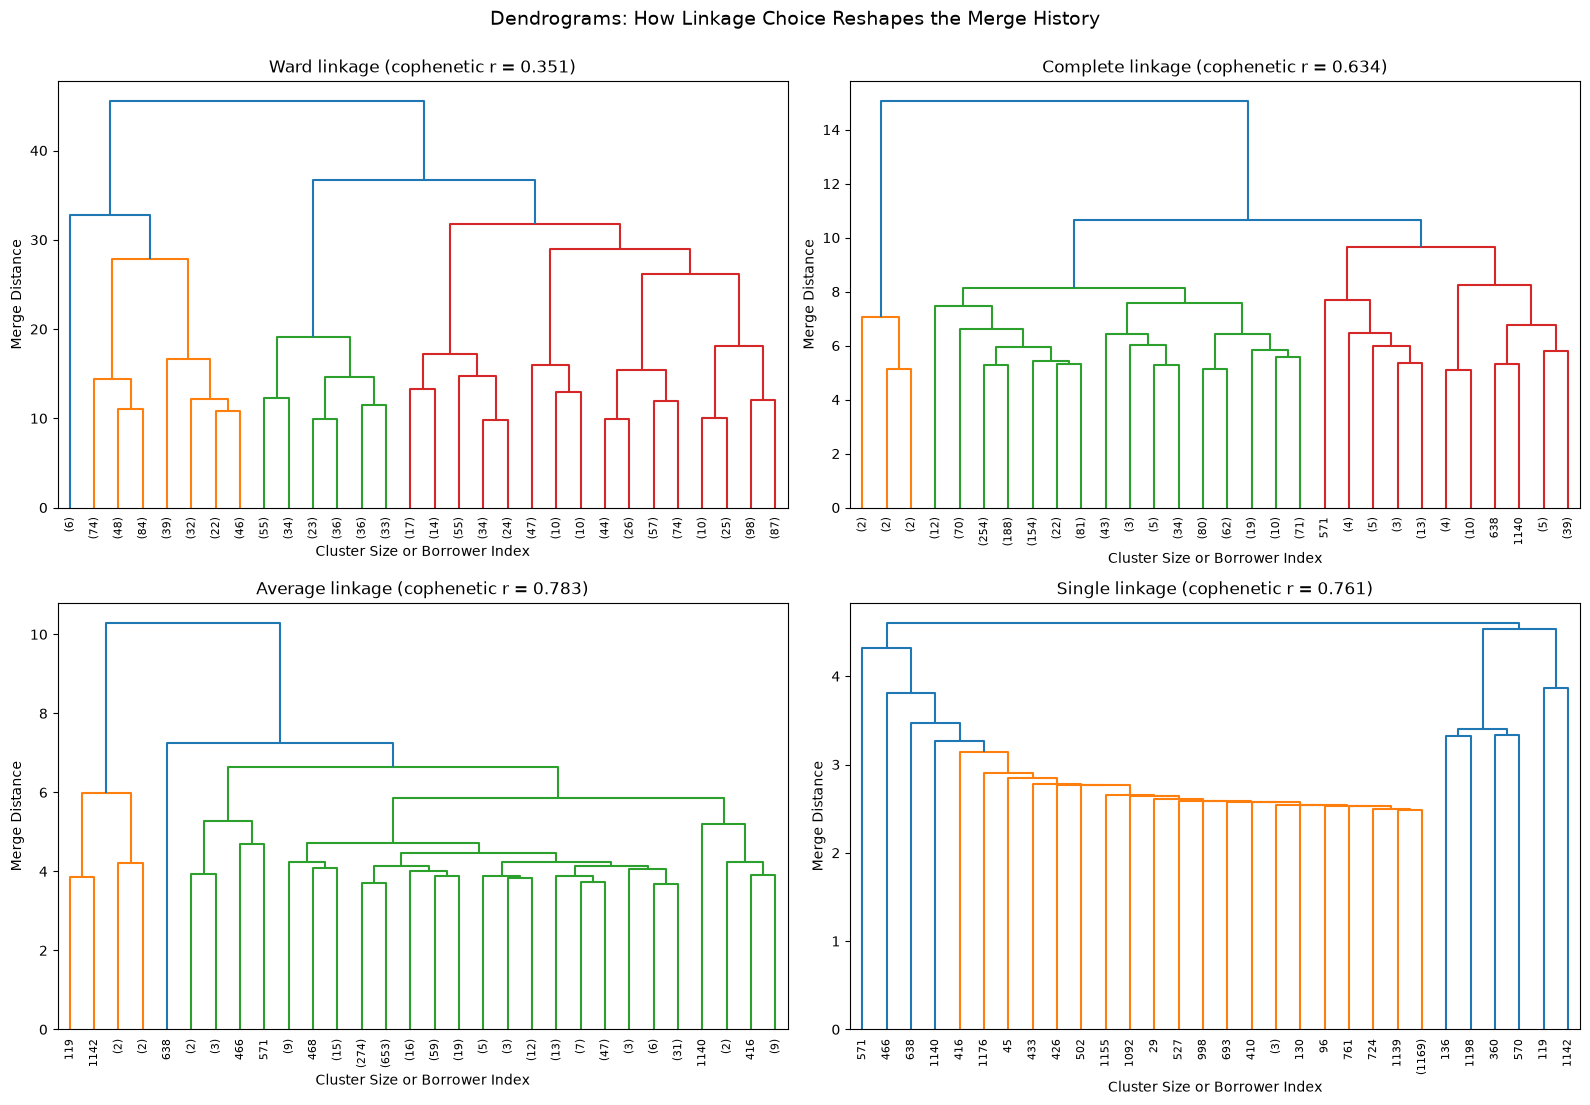

Largest Merge Distances by Linkage Method
(a large final gap indicates well-separated top-level groups)
 Linkage  Final Merge Height  Largest Gap Near Top  Gap as Share of Final Height
    ward             45.5362                8.8394                        0.1941
complete             15.0577                4.4041                        0.2925
 average             10.2904                3.0473                        0.2961
  single              4.6040                0.4529                        0.0984


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

dendrogram_linkages = {}

for axis, method in zip(axes, linkage_methods):
    linkage_matrix = linkage(
        X_dendrogram,
        method=method,
        metric="euclidean"
    )

    dendrogram_linkages[method] = linkage_matrix

    dendrogram(
        linkage_matrix,
        ax=axis,
        truncate_mode="lastp",
        p=30,
        show_leaf_counts=True,
        no_labels=False,
        leaf_rotation=90,
        leaf_font_size=8
    )

    correlation, _ = cophenet(
        linkage_matrix,
        pdist(X_dendrogram, metric="euclidean")
    )

    axis.set_title(
        f"{method.capitalize()} linkage "
        f"(cophenetic r = {correlation:.3f})"
    )
    axis.set_xlabel("Cluster Size or Borrower Index")
    axis.set_ylabel("Merge Distance")

plt.suptitle(
    "Dendrograms: How Linkage Choice Reshapes the Merge History",
    y=1.00,
    fontsize=14
)
plt.tight_layout()
plt.show()

print("Largest Merge Distances by Linkage Method")
print("(a large final gap indicates well-separated top-level groups)")

merge_gap_summary = []

for method in linkage_methods:
    merge_heights = dendrogram_linkages[method][:, 2]
    top_merges = np.sort(merge_heights)[-6:]
    gaps = np.diff(top_merges)

    merge_gap_summary.append({
        "Linkage": method,
        "Final Merge Height": top_merges[-1],
        "Largest Gap Near Top": gaps.max() if len(gaps) > 0 else np.nan,
        "Gap as Share of Final Height": (
            gaps.max() / top_merges[-1] if len(gaps) > 0 else np.nan
        )
    })

print(pd.DataFrame(merge_gap_summary).round(4).to_string(index=False))

**Cutting the Ward tree**


Best Ward cut by silhouette: k=2

Ward Cluster Profiles at k=2
         Borrowers  Median_Income  Median_Loan  Mean_Debt_Burden  Mean_Interest_Rate  Median_Age  Default_Rate  Population Share
cluster                                                                                                                         
1              934        55000.0      15000.0            0.2934             11.2242        25.0        0.4036            0.2335
2             3066        56000.0       6875.0            0.1357             10.9909        26.0        0.1673            0.7665

Sample default rate: 0.2225
Default rate spread across Ward clusters: 0.2363
Risk ratio, highest to lowest: 2.41x


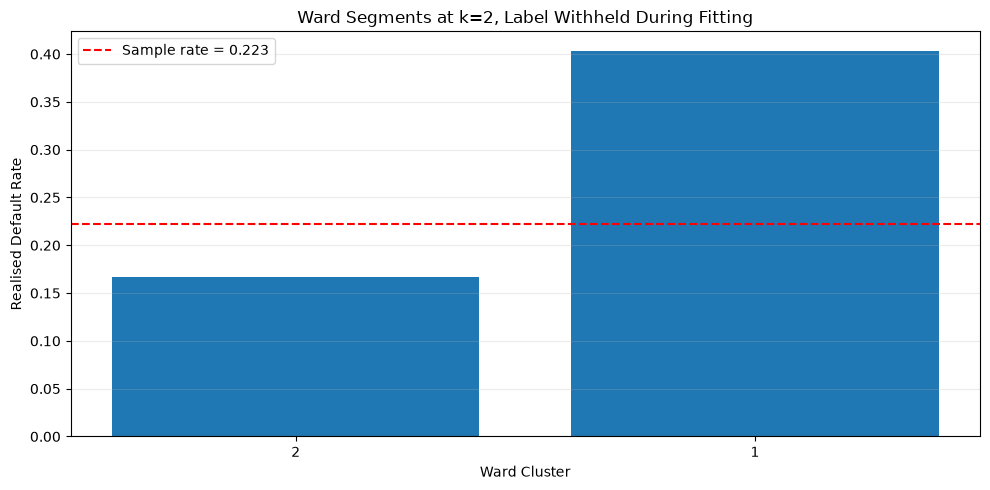

In [11]:
ward_linkage = linkage_matrices["ward"]

ward_silhouettes = hierarchical_df[
    hierarchical_df["Linkage"] == "ward"
]

best_ward_k = int(
    ward_silhouettes.loc[
        ward_silhouettes["Silhouette"].idxmax(),
        "Requested k"
    ]
)

print(f"Best Ward cut by silhouette: k={best_ward_k}")

ward_labels = fcluster(
    ward_linkage,
    t=best_ward_k,
    criterion="maxclust"
)

ward_profile_frame = df_hierarchical.copy()
ward_profile_frame["cluster"] = ward_labels

ward_profile = ward_profile_frame.groupby("cluster").agg(
    Borrowers=("loan_status", "size"),
    Median_Income=("person_income", "median"),
    Median_Loan=("loan_amnt", "median"),
    Mean_Debt_Burden=("loan_percent_income", "mean"),
    Mean_Interest_Rate=("loan_int_rate", "mean"),
    Median_Age=("person_age", "median"),
    Default_Rate=("loan_status", "mean")
).round(4)

ward_profile["Population Share"] = (
    ward_profile["Borrowers"] / ward_profile["Borrowers"].sum()
).round(4)

print(f"\nWard Cluster Profiles at k={best_ward_k}")
print(ward_profile.to_string())

ward_default_spread = (
    ward_profile["Default_Rate"].max()
    - ward_profile["Default_Rate"].min()
)

print(f"\nSample default rate: {y_hierarchical.mean():.4f}")
print(f"Default rate spread across Ward clusters: {ward_default_spread:.4f}")
print(
    "Risk ratio, highest to lowest:",
    f"{ward_profile['Default_Rate'].max() / max(ward_profile['Default_Rate'].min(), 1e-9):.2f}x"
)

plt.figure(figsize=(10, 5))
ward_sorted = ward_profile.sort_values("Default_Rate")
plt.bar(
    ward_sorted.index.astype(str),
    ward_sorted["Default_Rate"]
)
plt.axhline(
    y_hierarchical.mean(),
    linestyle="--",
    color="red",
    label=f"Sample rate = {y_hierarchical.mean():.3f}"
)
plt.xlabel("Ward Cluster")
plt.ylabel("Realised Default Rate")
plt.title(f"Ward Segments at k={best_ward_k}, Label Withheld During Fitting")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

**Do the Three Algorithms Agree?**

The three methods rest on incompatible premises. K-Means minimises variance around a fixed number of
centroids, DBSCAN grows clusters from regions of density and discards the rest, and Ward merges to
minimise variance increase while preserving a hierarchy. If all three converge on similar partitions,
that is strong evidence of real structure, because three different objective functions found the same
groups. If they disagree sharply, the honest conclusion is that this population has no single natural
segmentation and any reported clustering is partly a statement about the algorithm rather than about
the borrowers.

Agreement is measured two ways. Adjusted Rand index counts agreeing pairs of points, corrected for
chance. Adjusted mutual information measures shared information between the two labellings and handles
unbalanced cluster sizes more gracefully. Both read 1.0 for identical partitions and near 0.0 for
unrelated ones. The comparison runs on the hierarchical sample, since that is the only sample all three
methods can be fit on.

Adjusted Rand Index Between Methods
              K-Means  Ward HAC  Complete HAC  Average HAC  DBSCAN
K-Means        1.0000    0.3197       -0.0002      -0.0002 -0.0748
Ward HAC       0.3197    1.0000       -0.0003      -0.0003 -0.0777
Complete HAC  -0.0002   -0.0003        1.0000       1.0000 -0.0004
Average HAC   -0.0002   -0.0003        1.0000       1.0000 -0.0004
DBSCAN        -0.0748   -0.0777       -0.0004      -0.0004  1.0000

Adjusted Mutual Information Between Methods
              K-Means  Ward HAC  Complete HAC  Average HAC  DBSCAN
K-Means        1.0000    0.2364       -0.0002      -0.0002  0.0907
Ward HAC       0.2364    1.0000       -0.0003      -0.0003  0.0273
Complete HAC  -0.0002   -0.0003        1.0000       1.0000 -0.0004
Average HAC   -0.0002   -0.0003        1.0000       1.0000 -0.0004
DBSCAN         0.0907    0.0273       -0.0004      -0.0004  1.0000

Clusters Produced by Each Method on the Shared Sample
  K-Means       : 2 clusters, 0 noise points
  Ward HAC     

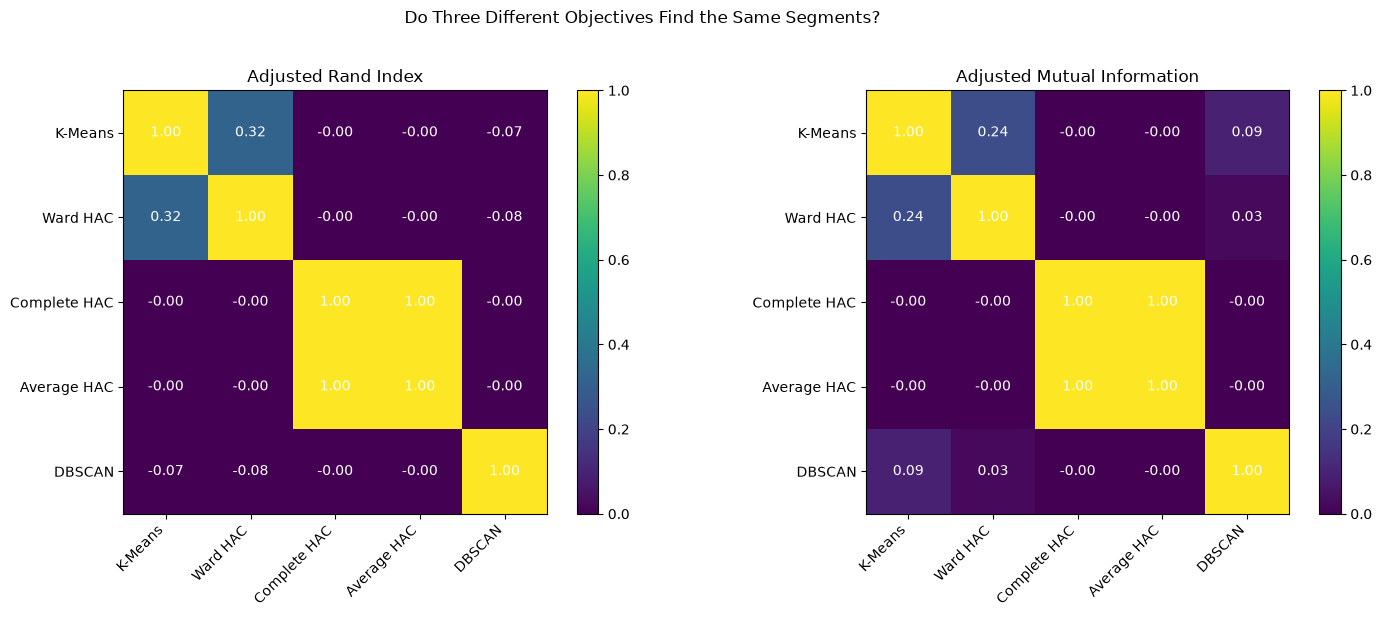

In [12]:
kmeans_comparison_labels = KMeans(
    n_clusters=best_ward_k,
    n_init=25,
    random_state=42
).fit_predict(X_hierarchical)

dbscan_comparison = DBSCAN(
    eps=chosen_eps,
    min_samples=chosen_min_samples,
    n_jobs=-1
).fit_predict(X_hierarchical)

complete_labels = fcluster(
    linkage_matrices["complete"],
    t=best_ward_k,
    criterion="maxclust"
)

average_labels = fcluster(
    linkage_matrices["average"],
    t=best_ward_k,
    criterion="maxclust"
)

partitions = {
    "K-Means": kmeans_comparison_labels,
    "Ward HAC": ward_labels,
    "Complete HAC": complete_labels,
    "Average HAC": average_labels,
    "DBSCAN": dbscan_comparison
}

method_names = list(partitions.keys())

rand_matrix = pd.DataFrame(
    index=method_names,
    columns=method_names,
    dtype=float
)

mutual_info_matrix = pd.DataFrame(
    index=method_names,
    columns=method_names,
    dtype=float
)

for first in method_names:
    for second in method_names:
        rand_matrix.loc[first, second] = adjusted_rand_score(
            partitions[first],
            partitions[second]
        )
        mutual_info_matrix.loc[first, second] = adjusted_mutual_info_score(
            partitions[first],
            partitions[second]
        )

print("Adjusted Rand Index Between Methods")
print(rand_matrix.round(4).to_string())

print("\nAdjusted Mutual Information Between Methods")
print(mutual_info_matrix.round(4).to_string())

print("\nClusters Produced by Each Method on the Shared Sample")
for name, labels in partitions.items():
    noise_count = int((labels == -1).sum())
    cluster_count = len(np.unique(labels[labels != -1]))
    print(
        f"  {name:<14}: {cluster_count} clusters, "
        f"{noise_count:,} noise points"
    )

kmeans_ward_agreement = rand_matrix.loc["K-Means", "Ward HAC"]

print(
    f"\nK-Means versus Ward agreement: {kmeans_ward_agreement:.4f}"
)

if kmeans_ward_agreement > 0.6:
    print(
        " K-Means and Ward largely agree, which is expected given "
        "that both minimise within-cluster variance, and it confirms the "
        "Week 10 partition was not an artifact of the K-Means algorithm "
        "specifically."
    )
else:
    print(
        " Even the two variance-minimising methods disagree "
        "substantially. On a dense continuous population, cluster boundaries "
        "are largely a choice made by the algorithm rather than a feature of "
        "the data, and this is the most important caveat attached to any "
        "segmentation reported from this dataset."
    )

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for axis, matrix, title in [
    (axes[0], rand_matrix, "Adjusted Rand Index"),
    (axes[1], mutual_info_matrix, "Adjusted Mutual Information")
]:
    image = axis.imshow(
        matrix.values.astype(float),
        cmap="viridis",
        vmin=0,
        vmax=1
    )
    axis.set_xticks(range(len(method_names)))
    axis.set_yticks(range(len(method_names)))
    axis.set_xticklabels(method_names, rotation=45, ha="right")
    axis.set_yticklabels(method_names)
    axis.set_title(title)

    for row in range(len(method_names)):
        for column in range(len(method_names)):
            axis.text(
                column,
                row,
                f"{matrix.values[row, column]:.2f}",
                ha="center",
                va="center",
                color="white"
            )

    plt.colorbar(image, ax=axis, fraction=0.046)

plt.suptitle("Do Three Different Objectives Find the Same Segments?", y=1.02)
plt.tight_layout()
plt.show()